# Análisis del Dataset_Balanceado_700

Este script cuenta cuántas imágenes hay por cada clase en el dataset `Dataset_Balanceado_700` y verifica sus dimensiones. 
Dado que los archivos son `.npz`, se itera sobre todos los archivos, se cargan y se suman las imágenes contenidas en cada uno.

In [1]:
import os
import numpy as np

# Ruta del dataset
dataset_path = 'Dataset_Balanceado_700'

if not os.path.exists(dataset_path):
    # Ajuste de ruta si se corre desde Propuesta1/
    if os.path.exists('../Dataset_Balanceado_700'):
        dataset_path = '../Dataset_Balanceado_700'
    else:
        print(f"Error: La carpeta '{dataset_path}' no se encuentra en el directorio actual.")

if os.path.exists(dataset_path):
    # Obtener las carpetas de las clases
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    
    print(f"{'Clase':<25} | {'Archivos':<10} | {'Total Imágenes':<15} | {'Dimensiones (WxH)':<20}")
    print("-" * 80)
    
    total_dataset_images = 0
    
    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name)
        files = [f for f in os.listdir(class_dir) if f.lower().endswith('.npz')]
        
        num_files = len(files)
        total_class_images = 0
        dims_set = set()
        
        for file_name in files:
            file_path = os.path.join(class_dir, file_name)
            try:
                with np.load(file_path) as data:
                    # Basado en la salida anterior, la clave es 'imagenes'
                    if 'imagenes' in data:
                        imgs = data['imagenes']
                        # Asumimos formato (N, H, W) donde N es el numero de imagenes
                        n_imgs = imgs.shape[0]
                        total_class_images += n_imgs
                        
                        if len(imgs.shape) >= 3:
                             dims_set.add(f"{imgs.shape[2]}x{imgs.shape[1]}") # WxH
                    else:
                        # Si no encuentra 'imagenes', intentar listar claves disponibles
                        print(f"Advertencia: 'imagenes' no encontrado en {file_name}. Claves: {list(data.files)}")

            except Exception as e:
                print(f"Error leyendo {file_name}: {e}")

        total_dataset_images += total_class_images
        
        dims_summary = ", ".join(list(dims_set)) if dims_set else "N/A"
        
        print(f"{class_name:<25} | {num_files:<10} | {total_class_images:<15} | {dims_summary:<20}")

    print("-" * 80)
    print(f"Total de imágenes en el dataset: {total_dataset_images}")

Clase                     | Archivos   | Total Imágenes  | Dimensiones (WxH)   
--------------------------------------------------------------------------------
Adenoma_hipofisario       | 62         | 699             | 128x128             
Glioma                    | 89         | 699             | 128x128             
Meningioma                | 82         | 700             | 128x128             
--------------------------------------------------------------------------------
Total de imágenes en el dataset: 2098


# Implementación de CNN Cuántica con Validación Cruzada Estratificada (5-Fold) - Propuesta Extra

En esta sección se implementa el flujo de trabajo completo, pero con **4 Feature Maps** (uno por cada qubit de salida).
Además, se guardan los feature maps resultantes en la carpeta `Feature_maps`.

1. **Preprocesamiento Cuántico**: Se aplica convolución cuántica a las imágenes (4 canales de salida).
2. **Guardado de Feature Maps**: Se almacenan las imágenes resultantes.
3. **División de Datos**: Se respeta la estructura de pacientes (archivos .npz) para evitar data leakage. Se separa un 15% para Test y el resto para 5-Fold CV.
4. **Entrenamiento**: Se entrena una Red Neuronal (MLP) sobre las características cuánticas.
5. **Evaluación**: Se reportan métricas de rendimiento.

In [2]:
import sys
# Aseguramos que se pueda importar quantum_utils si está en el mismo directorio
sys.path.append('.')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import quantum_utils as qu

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo de entrenamiento (Red Neuronal): {device}")

Usando dispositivo de entrenamiento (Red Neuronal): cuda


In [3]:
class RedNeuronalGeneral(nn.Module):
    def __init__(self, input_shape, num_classes=3):
        super(RedNeuronalGeneral, self).__init__()
        
        # 1. Calculamos dinámicamente el tamaño aplanado (Flatten)
        self.input_dim = np.prod(input_shape)
        # Ahora input_shape[0] será 4 (en lugar de 1)
        
        # print(f"Inicializando red para entrada {input_shape} -> {self.input_dim} neuronas de entrada.")

        # 2. Definimos la arquitectura Flatten + MLP
        #       Flatten -> Dense -> Dense -> Out
        
        self.flatten = nn.Flatten()
        
        self.layers = nn.Sequential(
            # Bloque Denso 1 
            nn.Linear(self.input_dim, 256), # De n entradas a 256 neuronas
            nn.BatchNorm1d(256), # Batch Normalization
            nn.LeakyReLU(0.1), # Activación LeakyReLU alpha=0.1
            nn.Dropout(0.3), # Dropout 30%
            
            # Bloque Denso 2
            nn.Linear(256, 128), # De 256 a 128 neuronas
            nn.BatchNorm1d(128), # Batch Normalization
            nn.LeakyReLU(0.1), # Activación LeakyReLU alpha=0.1
            nn.Dropout(0.2), # Dropout 20%
            
            # Capa de Salida (3 clases: Meningioma, Glioma, T. Pituitario)
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

In [4]:
def cargar_y_procesar_dataset(dataset_path, num_qubits=4, embedding='amplitude', feature_maps=4, max_images_per_class=None, save_feature_maps=True):
    """
    Carga los archivos .npz, aplica convolución cuántica y estructura los datos para CV.
    Devuelve:
        - data_features: Lista de tensores procesados (imágenes)
        - data_labels: Lista de etiquetas
        - data_groups: Lista de IDs de pacientes (para garantizar CV estratificado por grupo)
        
    Cambios:
        - feature_maps = 4 por defecto (para medir los 4 qubits).
        - save_feature_maps = True guarda las imágenes en la carpeta 'Feature_maps'.
        - Si ya existen las características guardadas, las carga en lugar de recalcularlas.
    """
    
    features_list = []
    labels_list = []
    groups_list = []
    
    # Crear carpeta principal para mapas de características
    base_map_dir = "Feature_maps"
    if save_feature_maps and not os.path.exists(base_map_dir):
        os.makedirs(base_map_dir)
    
    # Mapeo de clases a enteros
    class_map = {}
    if os.path.exists(dataset_path):
        classes = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    else:
        # Si no existe dataset_path, intenta inferir clases si existe la carpeta Feature_maps
        if os.path.exists(base_map_dir):
            classes = sorted([d for d in os.listdir(base_map_dir) if os.path.isdir(os.path.join(base_map_dir, d))])
        else:
            classes = []
            
    for idx, c in enumerate(classes):
        class_map[c] = idx
    
    print(f"Mapeo de Clases: {class_map}")
    
    for class_name in classes:
        # Directorios
        class_dir = os.path.join(dataset_path, class_name) if os.path.exists(dataset_path) else None
        class_map_dir = os.path.join(base_map_dir, class_name)
        
        if save_feature_maps and not os.path.exists(class_map_dir):
            os.makedirs(class_map_dir)
            
        # Si tenemos el dataset original, iteramos sobre los npz
        if class_dir and os.path.exists(class_dir):
            files = [f for f in os.listdir(class_dir) if f.lower().endswith('.npz')]
            if max_images_per_class:
                files = files[:max_images_per_class]
                
            print(f"Procesando clase {class_name} ({len(files)} pacientes)...")
            
            for file_name in tqdm(files, desc=f"Clase {class_name}"):
                file_path = os.path.join(class_dir, file_name)
                patient_id = file_name.replace('.npz', '')
                
                try:
                    with np.load(file_path) as data:
                        if 'imagenes' in data:
                            imgs = data['imagenes'] # Shape (N, H, W)
                            
                            for i in range(imgs.shape[0]):
                                img = imgs[i]
                                
                                maps_exist = True
                                map_paths = []
                                for k in range(feature_maps):
                                    save_filename = f"{patient_id}_img{i}_map{k+1}.png"
                                    save_path = os.path.join(class_map_dir, save_filename)
                                    map_paths.append(save_path)
                                    if not os.path.exists(save_path):
                                        maps_exist = False
                                        break
                                
                                if maps_exist:
                                    # Cargar características existentes
                                    from PIL import Image
                                    channels = []
                                    for path in map_paths:
                                        img_map = np.array(Image.open(path).convert('L'), dtype=np.float32)
                                        # Normalizar (asumimos que al guardar con imsave se mapea a 0-255)
                                        img_map = img_map / 255.0
                                        channels.append(img_map)
                                    
                                    q_feat_tensor = torch.tensor(np.stack(channels, axis=0), dtype=torch.float32)
                                else:
                                    # --- CONVOLUCIÓN CUÁNTICA ---
                                    q_feat = qu.quantum_conv(img, num_qubits, embedding, feature_maps)
                                    
                                    # --- GUARDAR FEATURE MAPS ---
                                    if save_feature_maps:
                                        for k in range(q_feat.shape[2]):
                                            feature_map_k = q_feat[:, :, k]
                                            save_filename = f"{patient_id}_img{i}_map{k+1}.png"
                                            save_path = os.path.join(class_map_dir, save_filename)
                                            plt.imsave(save_path, feature_map_k, cmap='gray')
                                    
                                    # Transponer a formato PyTorch (C, H, W)
                                    q_feat_tensor = torch.tensor(q_feat, dtype=torch.float32).permute(2, 0, 1)
                                
                                features_list.append(q_feat_tensor)
                                labels_list.append(class_map[class_name])
                                groups_list.append(patient_id)
                                
                except Exception as e:
                    print(f"Error al procesar {file_name}: {e}")
                    raise e
        else:
            # Si no existe dataset original, leemos directamente de Feature_maps
            print(f"Dataset original no encontrado. Leyendo desde Feature_maps para clase {class_name}...")
            png_files = [f for f in os.listdir(class_map_dir) if f.endswith('.png')]
            
            # Agrupar por paciente e índice de imagen
            img_groups = {}
            for f in png_files:
                parts = f.split('_img')
                if len(parts) != 2: continue
                patient_id = parts[0]
                rest = parts[1]
                if '_map' not in rest: continue
                i_str, map_str = rest.split('_map')
                i = int(i_str)
                k = int(map_str.replace('.png', ''))
                
                if (patient_id, i) not in img_groups:
                    img_groups[(patient_id, i)] = {}
                img_groups[(patient_id, i)][k] = os.path.join(class_map_dir, f)
                
            # Solo procesar los limitados por max_images si es el caso (pacientes unicos)
            unique_patients = list(set([pid for pid, _ in img_groups.keys()]))
            if max_images_per_class:
                unique_patients = unique_patients[:max_images_per_class]
                
            for (patient_id, i), maps_dict in tqdm(img_groups.items(), desc=f"Clase {class_name} cargando PNGs"):
                if patient_id not in unique_patients:
                    continue
                channels = []
                for k in range(1, feature_maps + 1):
                    if k in maps_dict:
                        from PIL import Image
                        img_map = np.array(Image.open(maps_dict[k]).convert('L'), dtype=np.float32) / 255.0
                        channels.append(img_map)
                
                if len(channels) == feature_maps:
                    q_feat_tensor = torch.tensor(np.stack(channels, axis=0), dtype=torch.float32)
                    features_list.append(q_feat_tensor)
                    labels_list.append(class_map[class_name])
                    groups_list.append(patient_id)
                
    return features_list, labels_list, groups_list

# Parametros Cuánticos Modificados para Propuesta Extra
NUM_QUBITS = 4
EMBEDDING = 'amplitude'
FEATURE_MAPS = 4 # Mediciones en los 4 qubits

# ADVERTENCIA: Esto puede tardar mucho más porque son 4 mediciones y IO de disco.
# Para probar el flujo primero, puedes descomentar 'max_images_per_class=2'
print("Iniciando extracción de características cuánticas (4 Mapas) y guardado de imágenes...")
X_raw, y_raw, group_raw = cargar_y_procesar_dataset(dataset_path, 
                                                num_qubits=NUM_QUBITS, 
                                                embedding=EMBEDDING, 
                                                feature_maps=FEATURE_MAPS,
                                                # max_images_per_class=2 # Descomentar para debug rapido
                                                save_feature_maps=True
                                                )

# Convertir a tensores apilados
X_all = torch.stack(X_raw)
y_all = torch.tensor(y_raw, dtype=torch.long)
groups_all = np.array(group_raw)

print(f"\nProcesamiento Completado.")
print(f"X shape: {X_all.shape}") # Debería ser (N, 4, 32, 32)
print(f"y shape: {y_all.shape}")
print(f"Grupos (Pacientes): {len(np.unique(groups_all))} únicos.")


Iniciando extracción de características cuánticas (4 Mapas) y guardado de imágenes...
Mapeo de Clases: {'Adenoma_hipofisario': 0, 'Glioma': 1, 'Meningioma': 2}
Procesando clase Adenoma_hipofisario (62 pacientes)...


Clase Adenoma_hipofisario:   0%|          | 0/62 [00:00<?, ?it/s]

Procesando clase Glioma (89 pacientes)...


Clase Glioma:   0%|          | 0/89 [00:00<?, ?it/s]

Procesando clase Meningioma (82 pacientes)...


Clase Meningioma:   0%|          | 0/82 [00:00<?, ?it/s]


Procesamiento Completado.
X shape: torch.Size([2098, 4, 32, 32])
y shape: torch.Size([2098])
Grupos (Pacientes): 233 únicos.


In [5]:
# --- ESTRATEGIA DE DIVISIÓN DE DATOS ---
# 1. Separar Test Set (15% de PACIENTES) preservando estratificación
#    Primero identificamos etiquetas por paciente para estratificar
unique_patients, patient_indices = np.unique(groups_all, return_index=True)
patient_labels = y_all[patient_indices].numpy()

train_val_patients, test_patients = train_test_split(unique_patients, 
                                                    test_size=0.15, 
                                                    stratify=patient_labels,
                                                    random_state=42)

print(f"Total Pacientes: {len(unique_patients)}")
print(f"Pacientes Train/Val: {len(train_val_patients)}")
print(f"Pacientes Test: {len(test_patients)}")

# Crear máscaras booleanas para filtrar X_all y y_all
# np.isin verifica si cada elemento de groups_all está en la lista de pacientes
mask_train_val = np.isin(groups_all, train_val_patients)
mask_test = np.isin(groups_all, test_patients)

X_train_val = X_all[mask_train_val]
y_train_val = y_all[mask_train_val]
groups_train_val = groups_all[mask_train_val]

X_test = X_all[mask_test]
y_test = y_all[mask_test]

print(f"Imágenes Train/Val: {len(X_train_val)}")
print(f"Imágenes Test: {len(X_test)}")

Total Pacientes: 233
Pacientes Train/Val: 198
Pacientes Test: 35
Imágenes Train/Val: 1770
Imágenes Test: 328


In [6]:
# --- 5-FOLD CROSS VALIDATION STRATIFIED ---
BATCH_SIZE = 32
EPOCHS = 50
N_SPLITS = 5

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS)

fold_metrics = []
history_per_fold = []

print(f"Iniciando {N_SPLITS}-Fold Cross Validation...")

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_val, y_train_val, groups_train_val)):
    print(f"\nFold {fold+1}/{N_SPLITS}")
    
    # Crear datasets para el fold actual
    # Convertir a Tensores si no lo son
    X_f_train, y_f_train = X_train_val[train_idx], y_train_val[train_idx]
    X_f_val, y_f_val = X_train_val[val_idx], y_train_val[val_idx]
    
    train_ds = TensorDataset(X_f_train, y_f_train)
    val_ds = TensorDataset(X_f_val, y_f_val)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Inicializar Modelo
    # Input shape: (C, H, W). Aquí C será 4.
    input_shape = X_all.shape[1:]
    model = RedNeuronalGeneral(input_shape=input_shape, num_classes=3).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    # Historial para graficar
    fold_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(EPOCHS):
        # Train
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct_val / total_val
        
        fold_history['train_loss'].append(avg_train_loss)
        fold_history['val_loss'].append(avg_val_loss)
        fold_history['val_acc'].append(val_accuracy)
        
        if(epoch % 10 == 0):
            print(f"  Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
    
    print(f"  Final Val Acc Fold {fold+1}: {fold_history['val_acc'][-1]:.2f}%")
    history_per_fold.append(fold_history)
    fold_metrics.append(fold_history['val_acc'][-1])

print("\n--- Resultados Cross-Validation ---")
print(f"Accuracy promedio: {np.mean(fold_metrics):.2f}% +/- {np.std(fold_metrics):.2f}%")

Iniciando 5-Fold Cross Validation...

Fold 1/5
  Epoch 1: Train Loss: 0.5286 | Val Acc: 70.90%
  Epoch 11: Train Loss: 0.0541 | Val Acc: 62.99%
  Epoch 21: Train Loss: 0.0201 | Val Acc: 68.64%
  Epoch 31: Train Loss: 0.0176 | Val Acc: 77.68%
  Epoch 41: Train Loss: 0.0079 | Val Acc: 81.07%
  Final Val Acc Fold 1: 79.66%

Fold 2/5
  Epoch 1: Train Loss: 0.5005 | Val Acc: 79.38%
  Epoch 11: Train Loss: 0.0312 | Val Acc: 60.17%
  Epoch 21: Train Loss: 0.0531 | Val Acc: 81.07%
  Epoch 31: Train Loss: 0.0061 | Val Acc: 83.33%
  Epoch 41: Train Loss: 0.0068 | Val Acc: 83.90%
  Final Val Acc Fold 2: 71.47%

Fold 3/5
  Epoch 1: Train Loss: 0.5187 | Val Acc: 54.08%
  Epoch 11: Train Loss: 0.0347 | Val Acc: 80.56%
  Epoch 21: Train Loss: 0.0698 | Val Acc: 77.75%
  Epoch 31: Train Loss: 0.0215 | Val Acc: 80.56%
  Epoch 41: Train Loss: 0.0105 | Val Acc: 83.38%
  Final Val Acc Fold 3: 79.72%

Fold 4/5
  Epoch 1: Train Loss: 0.5391 | Val Acc: 64.97%
  Epoch 11: Train Loss: 0.0566 | Val Acc: 59.04%
 

# Validación Leave-One-Subject-Out (LOSO)

Adicionalmente a la validación cruzada 5-fold, a continuación se realiza la validación **Leave-One-Subject-Out (LOSO)**.
En este esquema, en cada iteración se deja un paciente completo (todas sus imágenes) de los datos de entrenamiento como conjunto de validación, y se entrena con el resto.


In [9]:
# --- LEAVE-ONE-SUBJECT-OUT (LOSO) CROSS VALIDATION ---
from sklearn.model_selection import LeaveOneGroupOut
import time

logo = LeaveOneGroupOut()

loso_fold_metrics = []

# Nota: Aplicamos LOSO en el conjunto X_train_val para mantener la congruencia con la validación 5-fold previa.
# Alternativamente, podría aplicarse a X_all, pero esto respetará el conjunto de pruebas que se reservó inicialmente.
n_splits_loso = logo.get_n_splits(X_train_val, y_train_val, groups_train_val)
print(f"Iniciando Leave-One-Subject-Out (LOSO) Cross Validation con {n_splits_loso} pacientes...")

# Descomentar para ejecutar (puede tardar bastante)
for fold, (train_idx, val_idx) in enumerate(logo.split(X_train_val, y_train_val, groups_train_val)):
    
    X_f_train, y_f_train = X_train_val[train_idx], y_train_val[train_idx]
    X_f_val, y_f_val = X_train_val[val_idx], y_train_val[val_idx]
    
    train_ds = TensorDataset(X_f_train, y_f_train)
    val_ds = TensorDataset(X_f_val, y_f_val)
    
    # Batch size puede ser el mismo que antes (ej. 32)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Inicializar Modelo
    input_shape = X_all.shape[1:]
    model = RedNeuronalGeneral(input_shape=input_shape, num_classes=3).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    # Bucle de entrenamiento
    for epoch in range(EPOCHS):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # Validación al final de todas las épocas para el fold
    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    # Si total_val es 0 (raro, pero posible si grupos vacíos), evitar division por cero
    val_accuracy = 100 * correct_val / total_val if total_val > 0 else 0
    loso_fold_metrics.append(val_accuracy)
    
    # Imprimir progreso cada 10 pacientes o al final
    if (fold + 1) % 10 == 0 or (fold + 1) == n_splits_loso:
        print(f"  Completado LOSO Fold {fold+1}/{n_splits_loso} | Val Acc del fold: {val_accuracy:.2f}%")

print("\n--- Resultados Leave-One-Subject-Out (LOSO) ---")
print(f"Accuracy promedio LOSO: {np.mean(loso_fold_metrics):.2f}% +/- {np.std(loso_fold_metrics):.2f}%")


Iniciando Leave-One-Subject-Out (LOSO) Cross Validation con 198 pacientes...
  Completado LOSO Fold 10/198 | Val Acc del fold: 100.00%
  Completado LOSO Fold 20/198 | Val Acc del fold: 38.46%
  Completado LOSO Fold 30/198 | Val Acc del fold: 100.00%
  Completado LOSO Fold 40/198 | Val Acc del fold: 75.00%
  Completado LOSO Fold 50/198 | Val Acc del fold: 12.50%
  Completado LOSO Fold 60/198 | Val Acc del fold: 100.00%
  Completado LOSO Fold 70/198 | Val Acc del fold: 100.00%
  Completado LOSO Fold 80/198 | Val Acc del fold: 90.91%
  Completado LOSO Fold 90/198 | Val Acc del fold: 71.43%
  Completado LOSO Fold 100/198 | Val Acc del fold: 50.00%
  Completado LOSO Fold 110/198 | Val Acc del fold: 0.00%
  Completado LOSO Fold 120/198 | Val Acc del fold: 100.00%
  Completado LOSO Fold 130/198 | Val Acc del fold: 88.89%
  Completado LOSO Fold 140/198 | Val Acc del fold: 73.33%
  Completado LOSO Fold 150/198 | Val Acc del fold: 90.00%
  Completado LOSO Fold 160/198 | Val Acc del fold: 57.14%


# Evaluación en Conjunto de Test

A continuación se evalúa el modelo resultante del último fold en el conjunto de Test reservado al inicio (15% de los datos).
Se muestran:
1. Matriz de Confusión.
2. Reporte de Clasificación.
3. F1-Score (Macro).


--- Reporte de Clasificación (Test Set) ---
              precision    recall  f1-score   support

     Adenoma       0.92      0.98      0.95       110
      Glioma       0.83      0.86      0.84       107
  Meningioma       0.83      0.74      0.78       111

    accuracy                           0.86       328
   macro avg       0.86      0.86      0.86       328
weighted avg       0.86      0.86      0.86       328

--- Matriz de Confusión ---


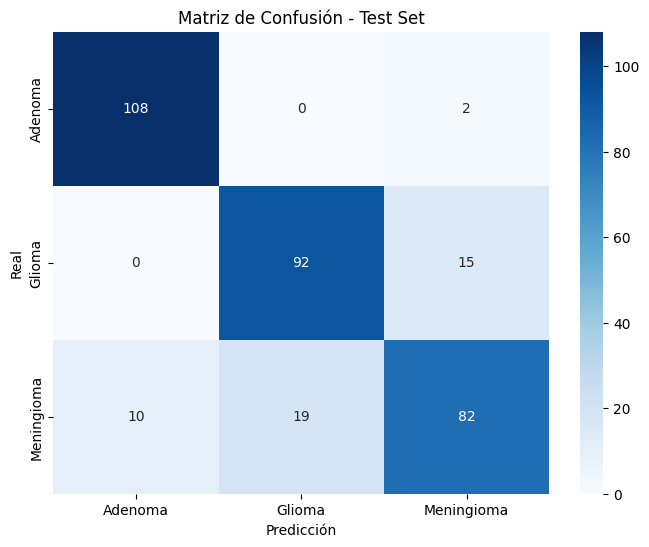


Macro F1 Score: 0.8575


In [7]:
# --- EVALUACIÓN EN CONJUNTO DE TEST ---
from sklearn.metrics import f1_score

# 1. Evaluar el modelo del último fold (o el actual en memoria) en el Test Set
model.eval()
y_pred_list = []
y_true_list = []

with torch.no_grad():
    # Crear DataLoader para Test
    test_ds = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        y_pred_list.extend(predicted.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

# 2. Métricas
print("\n--- Reporte de Clasificación (Test Set) ---")
print(classification_report(y_true_list, y_pred_list, target_names=['Adenoma', 'Glioma', 'Meningioma']))

print("--- Matriz de Confusión ---")
cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Adenoma', 'Glioma', 'Meningioma'], yticklabels=['Adenoma', 'Glioma', 'Meningioma'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Test Set')
plt.show()

# 3. Macro F1
macro_f1 = f1_score(y_true_list, y_pred_list, average='macro')
print(f"\nMacro F1 Score: {macro_f1:.4f}")